# FA2 - Logistic Regression\n\n**Dataset:** Kaggle Wine Quality (Red Wine)\n\nAll four models use the same `winequality-red.csv` dataset.


## 1. Import Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


## 2. Data Loading and Inspection


In [2]:

df = pd.read_csv("winequality-red.csv")

print("First 5 rows:")
print(df.head())

print("\nShape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData information:")
df.info()


First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2     

## 3. Exploratory Data Analysis


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

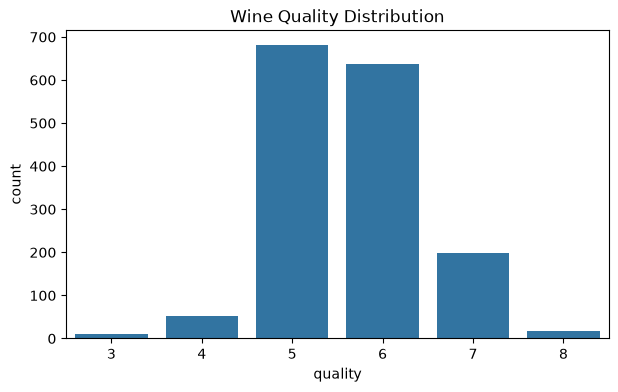

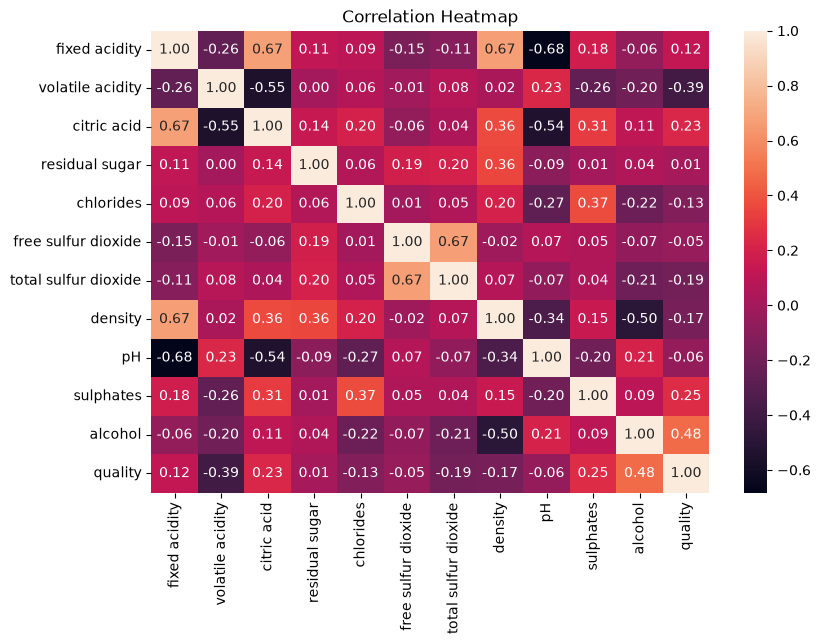

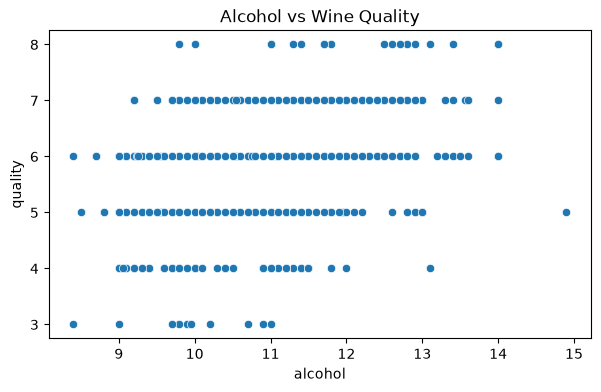


EDA observations:
- The target column is quality.
- The dataset contains numerical chemical properties of red wine.
- Alcohol shows a visible relationship with quality.
- The target has multiple quality classes.


In [3]:

print(df.describe())

print("\nQuality value counts:")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(7,4))
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")
plt.show()

plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x="alcohol", y="quality")
plt.title("Alcohol vs Wine Quality")
plt.show()

print("\nEDA observations:")
print("- The target column is quality.")
print("- The dataset contains numerical chemical properties of red wine.")
print("- Alcohol shows a visible relationship with quality.")
print("- The target has multiple quality classes.")


## 4. Data Preprocessing and Train/Test Split


In [4]:

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1279, 11)
Testing data: (320, 11)


## 5. Model Training


In [5]:

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model training completed.")


Model training completed.


## 6. Model Evaluation


Accuracy: 0.590625

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320


Confusion Matrix:
[[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]


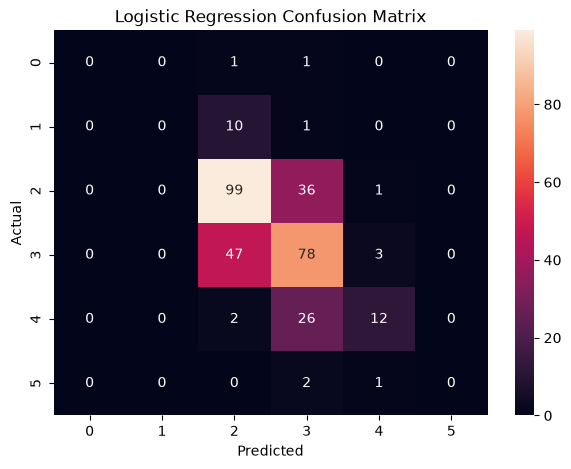

In [6]:

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 7. Conclusion


Logistic Regression is used for multiclass classification of wine quality. StandardScaler is used because the features have different ranges.
